# 🏦 NUST Bank - Qwen 3.5 4B Fine-Tuning Notebook

Fine-tune Qwen 3.5 4B on NUST Bank product knowledge using Unsloth + LoRA.

**Requirements:** GPU with CUDA 12.8, PyTorch 2.7.0+cu128

## Step 1: Install Dependencies

Install unsloth compatible with **torch 2.7.0 + CUDA 12.8**.

In [ ]:
%%capture
# Step 1a: Install unsloth with correct CUDA 12.8 + torch 2.7.0 support
!pip install --upgrade pip
!pip install --no-deps git+https://github.com/unslothai/unsloth-zoo.git
!pip install "unsloth[cu128-torch270] @ git+https://github.com/unslothai/unsloth.git" --no-build-isolation

# Step 1b: Install remaining dependencies (--no-deps to avoid overwriting torch)
!pip install --no-deps trl peft accelerate bitsandbytes datasets

In [ ]:
!pip install --upgrade "transformers>=5.2.0"

In [1]:
# Verify installation
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version:    {torch.version.cuda}")
print(f"GPU available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name:        {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:      {round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)} GB")

PyTorch version: 2.7.0+cu128
CUDA version:    12.8
GPU available:   True
GPU name:        NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory:      8.0 GB


## Step 2: Load Model with Unsloth + LoRA

In [1]:
from unsloth import FastLanguageModel
import torch
import os

# Fix for CUDA memory fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Keep seq length manageable for GPU VRAM
max_seq_length = 768

print("Downloading Qwen 3.5 4B...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-4B",
    max_seq_length = max_seq_length,
    dtype = None,              # Auto-detect best dtype
    load_in_4bit = True,       # 4-bit quantization to save VRAM
    trust_remote_code = True,
)

print("Applying LoRA adapters...")
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",  # Keeps VRAM low
    random_state = 3407,
)
print("✅ Model loaded and LoRA applied!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


c:\Users\Awais Nazir\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0405 20:32:11.740000 27504 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.4.2: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.996 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.7.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Qwen3_5 does not support SDPA - switching to fast eager.


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 723/723 [00:03<00:00, 230.79it/s]


Applying LoRA adapters...
Unsloth: Making `model.base_model.model.model.language_model` require gradients
✅ Model loaded and LoRA applied!


## Step 3: Prepare Training Data

In [2]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

# 1. Apply the Qwen 2.5 chat template (compatible with Qwen 3.5)
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen-2.5",
)

# 2. Load training data from JSONL file
dataset = load_dataset("json", data_files="finetuning_data_chat_fixed.jsonl", split="train")

# 3. Format the data for training
def formatting_prompts_func(examples):
    texts = []
    for convo in examples["messages"]:
        # Ensure every message content is a plain string (not a list)
        for msg in convo:
            if isinstance(msg["content"], list):
                msg["content"] = msg["content"][0]["text"]

        # Apply template with enable_thinking=False for direct banking answers
        text = tokenizer.apply_chat_template(
            convo,
            tokenize = False,
            add_generation_prompt = False,
            enable_thinking = False,
        )
        texts.append(text)

    return { "text" : texts }

dataset = dataset.map(formatting_prompts_func, batched = True)

print(f"✅ Success! Loaded {len(dataset)} rows of banking data.")
print("\n--- PREVIEW OF FORMATTED DATA ---")
print(dataset[0]["text"][:500])

Generating train split: 310 examples [00:00, 40990.99 examples/s]
Map:   0%|          | 0/310 [00:00<?, ? examples/s]Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
Kwargs passed to `processor.

✅ Success! Loaded 310 rows of banking data.

--- PREVIEW OF FORMATTED DATA ---
<|im_start|>system
You are a helpful customer support assistant for NUST Bank. Answer the customer's question accurately and concisely using the bank's product knowledge.<|im_end|>
<|im_start|>user
I would like to open an account with my son, do u have any product for kids?<|im_end|>
<|im_start|>assistant
Yes our product is Little Champs Account. It is designed specifically for minors (individuals below the age of 18 years). A child requires the help of a parental/legal guardian to open this acc


## Step 4: Configure Trainer

In [3]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,   # Effective batch size = 4
        warmup_steps = 10,
        num_train_epochs = 5,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        max_grad_norm = 0.3,
    ),
)
print("✅ Trainer configured!")

Unsloth: Tokenizing ["text"]: 100%|██████████| 310/310 [00:00<00:00, 4217.08 examples/s]

✅ Trainer configured!


## Step 5: Train the Model

In [4]:
# Check VRAM before starting
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name} | Max Memory: {max_memory} GB")
print(f"VRAM Reserved (Thanks to 4-bit!): {start_gpu_memory} GB\n")

print("🚀 Starting Training...")
trainer_stats = trainer.train()

print(f"\n✅ Training Complete! Time taken: {round(trainer_stats.metrics['train_runtime']/60, 2)} minutes.")
print(f"Final training loss: {trainer_stats.metrics['train_loss']:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.


GPU: NVIDIA GeForce RTX 4060 Laptop GPU | Max Memory: 7.996 GB
VRAM Reserved (Thanks to 4-bit!): 3.164 GB

🚀 Starting Training...


Step,Training Loss
1,11.035351
2,11.860162
3,11.216662
4,10.721810
5,10.396201
6,9.299001
7,9.441170
8,7.202450
9,6.236806
10,6.608104


KeyboardInterrupt: 

## Step 6: Save the LoRA Adapter

In [6]:
# Save the LoRA adapter weights
adapter_name = "qwen3.5_banking_lora"
model.save_pretrained(adapter_name)
tokenizer.save_pretrained(adapter_name)
print(f"💾 Adapter saved to folder: '{adapter_name}'!")

💾 Adapter saved to folder: 'qwen3.5_banking_lora'!


## Step 7: Test the Fine-Tuned Model

**Key fix:** Use plain string content (not list-of-dicts) and use the text tokenizer to avoid vision processor issues with Qwen 3.5.

In [7]:
from unsloth import FastLanguageModel
import torch

# 1. Enable 2x faster inference
FastLanguageModel.for_inference(model)

# 2. Grab the hidden text-only tokenizer to bypass all vision logic safely
if hasattr(tokenizer, "tokenizer"):
    text_tokenizer = tokenizer.tokenizer
else:
    text_tokenizer = tokenizer

# 3. Manually build the prompt using Qwen chat format
#    Using plain strings — NOT [{"type": "text", "text": "..."}] lists!
prompt = """<|im_start|>system
You are a helpful customer support assistant for NUST Bank. Answer the customer's question accurately and concisely using the bank's product knowledge.<|im_end|>
<|im_start|>user
What other Value added features does the Little Champs Account have?<|im_end|>
<|im_start|>assistant
"""

# 4. Tokenize with the text-only tokenizer (avoids vision processor errors)
inputs = text_tokenizer(prompt, return_tensors="pt").to("cuda")

print("\n--- QWEN 3.5 RESPONSE (Fine-Tuned) ---")

# 5. Generate with repetition penalty + sampling to avoid loops
outputs = model.generate(
    input_ids = inputs.input_ids,
    attention_mask = inputs.attention_mask,
    max_new_tokens = 256,
    use_cache = True,
    pad_token_id = text_tokenizer.eos_token_id,
    do_sample = True,
    temperature = 0.3,          # Low temp = more deterministic, less hallucination
    top_p = 0.9,
    repetition_penalty = 1.15,  # Penalizes repeated tokens — prevents loops
)

# 6. Decode only the new generated tokens (skip the prompt)
prompt_length = inputs.input_ids.shape[1]
response = text_tokenizer.batch_decode(outputs[:, prompt_length:], skip_special_tokens=True)[0]

print(response)



--- QWEN 3.5 RESPONSE (Fine-Tuned) ---
· Free First Cheque Book (Unlimited) *
· SMS Alerts on digital transactions
· E-statements facility
· Inter Branch Online Cash Withdrawal/ Deposit (Online)
· Internal Fund Transfer within NUST via branch (Online Transfer)
· I Net Banking & Mobile banking facilities for account holders above 18 years


In [8]:
# Test with multiple questions
test_questions = [
    "What is the Eligibility Criteria for NAA?",
    "Does NUST Bank offer a Digital Banking Account for Freelancers?",
    "What are the benefits of NUST Bank Auto Finance?",
    "What documents are required to open a Little Champs Account?",
    "What is the Target Market for NUST Special Deposit Account (ASDA)?",
]

for q in test_questions:
    prompt = f"""<|im_start|>system
You are a helpful customer support assistant for NUST Bank. Answer the customer's question accurately and concisely using the bank's product knowledge.<|im_end|>
<|im_start|>user
{q}<|im_end|>
<|im_start|>assistant
"""
    inputs = text_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        input_ids = inputs.input_ids,
        attention_mask = inputs.attention_mask,
        max_new_tokens = 256,
        use_cache = True,
        pad_token_id = text_tokenizer.eos_token_id,
        do_sample = True,
        temperature = 0.3,
        top_p = 0.9,
        repetition_penalty = 1.15,
    )
    prompt_length = inputs.input_ids.shape[1]
    response = text_tokenizer.batch_decode(outputs[:, prompt_length:], skip_special_tokens=True)[0]
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"A: {response}")



Q: What is the Eligibility Criteria for NAA?
A: Resident Pakistani individuals, including women, who do not maintain any other account with NUST Bank are eligible to open this account.

Q: Does NUST Bank offer a Digital Banking Account for Freelancers?
A: Yes, Freelancer Digital Account is specially designed to meet the banking needs of freelancers & sole proprietors offering digital services.

Q: What are the benefits of NUST Bank Auto Finance?
A: · Attractive financing rates starting from 10% p.a — Profit Payment System (PPS)
· Minimum age to avail loan is 21 years, however age not to exceed 65 at the time of application
· Loan tenure can be extended up to maximum 8 years or as per prevailing SOC/BOQ
· Application will be processed within 3 working days subject to complete application with required documents

Q: What documents are required to open a Little Champs Account?
A: • A photocopy of front page of CNIC of minor’s legal guardian (Parent/Guardian)
• Any one valid ID proof of l

## Step 8: Download the Adapter (for Colab)

In [ ]:
# Zip and download (only works in Google Colab)
import os
if 'google.colab' in str(get_ipython()):
    !zip -r qwen3.5_banking_lora.zip qwen3.5_banking_lora
    from google.colab import files
    files.download('qwen3.5_banking_lora.zip')
else:
    print(f"Adapter saved locally at: {os.path.abspath('qwen3.5_banking_lora')}")
    print("You can manually zip and transfer this folder.")

## Step 9: Training Loss Visualization

Plot the training loss curve with smoothed moving average and epoch boundaries.

In [9]:
# Install evaluation dependencies
!pip install rouge-score nltk matplotlib seaborn --quiet
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

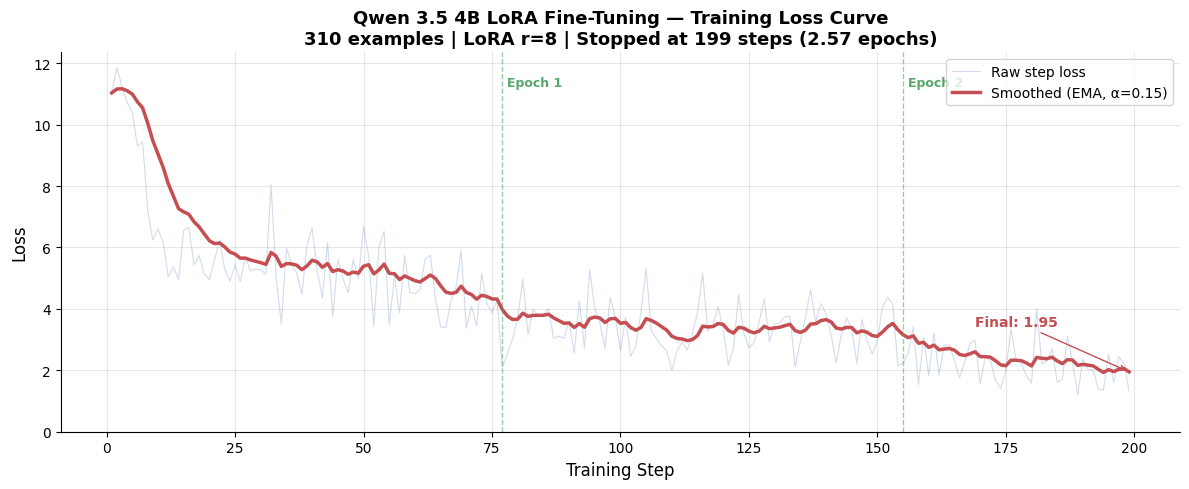


--- Training Summary ---
Total steps:    199
Epochs:         2.57
Initial loss:   11.04
Final loss:     1.32
Min loss:       1.20 (step 189)
Avg loss (last 20): 2.10
Loss reduction: 81.0%


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Load training losses
steps, losses = [], []
with open('training_step_losses.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('Step'):
            continue
        parts = line.split('\t')
        if len(parts) == 2:
            steps.append(int(parts[0]))
            losses.append(float(parts[1]))

steps = np.array(steps)
losses = np.array(losses)

# Smoothed loss (exponential moving average)
def ema(data, alpha=0.15):
    smoothed = np.zeros_like(data)
    smoothed[0] = data[0]
    for i in range(1, len(data)):
        smoothed[i] = alpha * data[i] + (1 - alpha) * smoothed[i-1]
    return smoothed

smoothed = ema(losses)

# Calculate epoch boundaries (310 examples, batch=1, grad_accum=4 → 77.5 steps/epoch)
steps_per_epoch = 310 / 4  # 77.5
total_epochs_completed = len(steps) / steps_per_epoch

# ── FIGURE 1: Training Loss Curve ──
fig, ax = plt.subplots(figsize=(12, 5))

# Raw loss (semi-transparent)
ax.plot(steps, losses, alpha=0.25, color='#4C72B0', linewidth=0.8, label='Raw step loss')

# Smoothed loss (bold)
ax.plot(steps, smoothed, color='#C44E52', linewidth=2.5, label='Smoothed (EMA, α=0.15)')

# Epoch boundary lines
for epoch in range(1, 4):
    epoch_step = int(epoch * steps_per_epoch)
    if epoch_step <= len(steps):
        ax.axvline(x=epoch_step, color='#55A868', linestyle='--', alpha=0.6, linewidth=1)
        ax.text(epoch_step + 1, max(losses) * 0.95, f'Epoch {epoch}',
                fontsize=9, color='#55A868', fontweight='bold')

# Styling
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Qwen 3.5 4B LoRA Fine-Tuning — Training Loss Curve\n'
             f'310 examples | LoRA r=8 | Stopped at {len(steps)} steps ({total_epochs_completed:.2f} epochs)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(losses) + 0.5)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate final loss
ax.annotate(f'Final: {smoothed[-1]:.2f}',
            xy=(steps[-1], smoothed[-1]),
            xytext=(steps[-1]-30, smoothed[-1]+1.5),
            arrowprops=dict(arrowstyle='->', color='#C44E52'),
            fontsize=10, fontweight='bold', color='#C44E52')

plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print(f'\n--- Training Summary ---')
print(f'Total steps:    {len(steps)}')
print(f'Epochs:         {total_epochs_completed:.2f}')
print(f'Initial loss:   {losses[0]:.2f}')
print(f'Final loss:     {losses[-1]:.2f}')
print(f'Min loss:       {min(losses):.2f} (step {steps[np.argmin(losses)]})')
print(f'Avg loss (last 20): {np.mean(losses[-20:]):.2f}')
print(f'Loss reduction: {((losses[0] - np.mean(losses[-20:])) / losses[0] * 100):.1f}%')

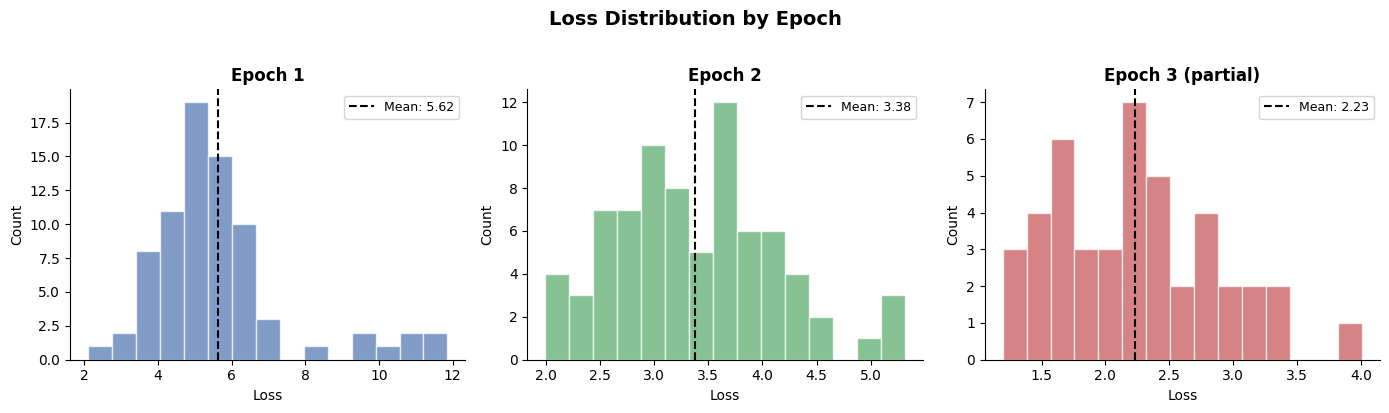

In [11]:
# ── FIGURE 2: Loss Distribution by Epoch ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

steps_per_ep = 310 / 4
epoch_ranges = [
    ('Epoch 1', 0, int(steps_per_ep)),
    ('Epoch 2', int(steps_per_ep), int(2 * steps_per_ep)),
    ('Epoch 3 (partial)', int(2 * steps_per_ep), len(losses)),
]

colors = ['#4C72B0', '#55A868', '#C44E52']
for ax, (label, start, end), color in zip(axes, epoch_ranges, colors):
    epoch_losses = losses[start:end]
    ax.hist(epoch_losses, bins=15, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(epoch_losses), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(epoch_losses):.2f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Loss')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Loss Distribution by Epoch', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loss_distribution_by_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Model Evaluation (ROUGE / BLEU / BERTScore)

Evaluate the fine-tuned model against ground truth answers from the training dataset.  
We use:
- **ROUGE-1/2/L** — Measures n-gram overlap (recall-oriented, best for longer answers)
- **BLEU** — Measures n-gram precision (good for shorter, factual answers)
- **Semantic Similarity** — Cosine similarity of sentence embeddings

In [12]:
import json
import random
import numpy as np
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

# 1. Load the fixed dataset
all_data = []
with open('finetuning_data_chat_fixed.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            all_data.append(json.loads(line))

# 2. Select evaluation samples — spread across different product categories
random.seed(42)
eval_indices = random.sample(range(len(all_data)), min(50, len(all_data)))
eval_data = [all_data[i] for i in eval_indices]

print(f'Evaluating on {len(eval_data)} samples from the dataset...')
print('This may take 5-10 minutes depending on your GPU.\n')

# 3. Run inference on each sample
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

if hasattr(tokenizer, 'tokenizer'):
    text_tokenizer = tokenizer.tokenizer
else:
    text_tokenizer = tokenizer

results = []
for idx, sample in enumerate(eval_data):
    # Extract question and ground truth
    question = ''
    ground_truth = ''
    for msg in sample['messages']:
        if msg['role'] == 'user':
            question = msg['content']
        elif msg['role'] == 'assistant':
            ground_truth = msg['content']

    # Build prompt
    prompt = f"""<|im_start|>system
You are a helpful customer support assistant for NUST Bank. Answer the customer's question accurately and concisely using the bank's product knowledge.<|im_end|>
<|im_start|>user
{question}<|im_end|>
<|im_start|>assistant
"""

    inputs = text_tokenizer(prompt, return_tensors='pt').to('cuda')
    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_new_tokens=256,
        use_cache=True,
        pad_token_id=text_tokenizer.eos_token_id,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.15,
    )
    prompt_length = inputs.input_ids.shape[1]
    predicted = text_tokenizer.batch_decode(
        outputs[:, prompt_length:], skip_special_tokens=True
    )[0].strip()

    results.append({
        'question': question,
        'ground_truth': ground_truth,
        'predicted': predicted,
    })

    if (idx + 1) % 10 == 0:
        print(f'  Completed {idx + 1}/{len(eval_data)} samples...')

print(f'\nAll {len(results)} samples generated!')

Evaluating on 50 samples from the dataset...
This may take 5-10 minutes depending on your GPU.

  Completed 10/50 samples...
  Completed 20/50 samples...
  Completed 30/50 samples...
  Completed 40/50 samples...
  Completed 50/50 samples...

All 50 samples generated!


In [18]:
# ── Compute ROUGE + BLEU scores ──
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
bleu_scores = []
exact_matches = 0

for r in results:
    gt = r['ground_truth']
    pred = r['predicted']

    # ROUGE
    rouge_result = scorer.score(gt, pred)
    rouge1_scores.append(rouge_result['rouge1'].fmeasure)
    rouge2_scores.append(rouge_result['rouge2'].fmeasure)
    rougeL_scores.append(rouge_result['rougeL'].fmeasure)

    # BLEU (sentence-level with smoothing)
    ref_tokens = word_tokenize(gt.lower())
    pred_tokens = word_tokenize(pred.lower())
    if len(ref_tokens) > 0 and len(pred_tokens) > 0:
        bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
    else:
        bleu = 0.0
    bleu_scores.append(bleu)

    # Exact match (normalized)
    if gt.strip().lower() == pred.strip().lower():
        exact_matches += 1

    r['rouge1'] = rouge_result['rouge1'].fmeasure
    r['rouge2'] = rouge_result['rouge2'].fmeasure
    r['rougeL'] = rouge_result['rougeL'].fmeasure
    r['bleu'] = bleu

# Summary
print('=' * 60)
print('        EVALUATION RESULTS SUMMARY')
print('=' * 60)
print(f'  Samples evaluated:   {len(results)}')
print(f'  Exact matches:       {exact_matches}/{len(results)} ({exact_matches/len(results)*100:.1f}%)')
print(f'')
print(f'  ROUGE-1 (F1):        {np.mean(rouge1_scores):.4f}  (±{np.std(rouge1_scores):.4f})')
print(f'  ROUGE-2 (F1):        {np.mean(rouge2_scores):.4f}  (±{np.std(rouge2_scores):.4f})')
print(f'  ROUGE-L (F1):        {np.mean(rougeL_scores):.4f}  (±{np.std(rougeL_scores):.4f})')
print(f'  BLEU:                {np.mean(bleu_scores):.4f}  (±{np.std(bleu_scores):.4f})')
print('=' * 60)

        EVALUATION RESULTS SUMMARY
  Samples evaluated:   50
  Exact matches:       5/50 (10.0%)

  ROUGE-1 (F1):        0.5080  (±0.2912)
  ROUGE-2 (F1):        0.3512  (±0.3494)
  ROUGE-L (F1):        0.4459  (±0.3024)
  BLEU:                0.2630  (±0.3451)


C:\Users\Awais Nazir\AppData\Local\Temp\ipykernel_27504\422252843.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=metrics, patch_artist=True,


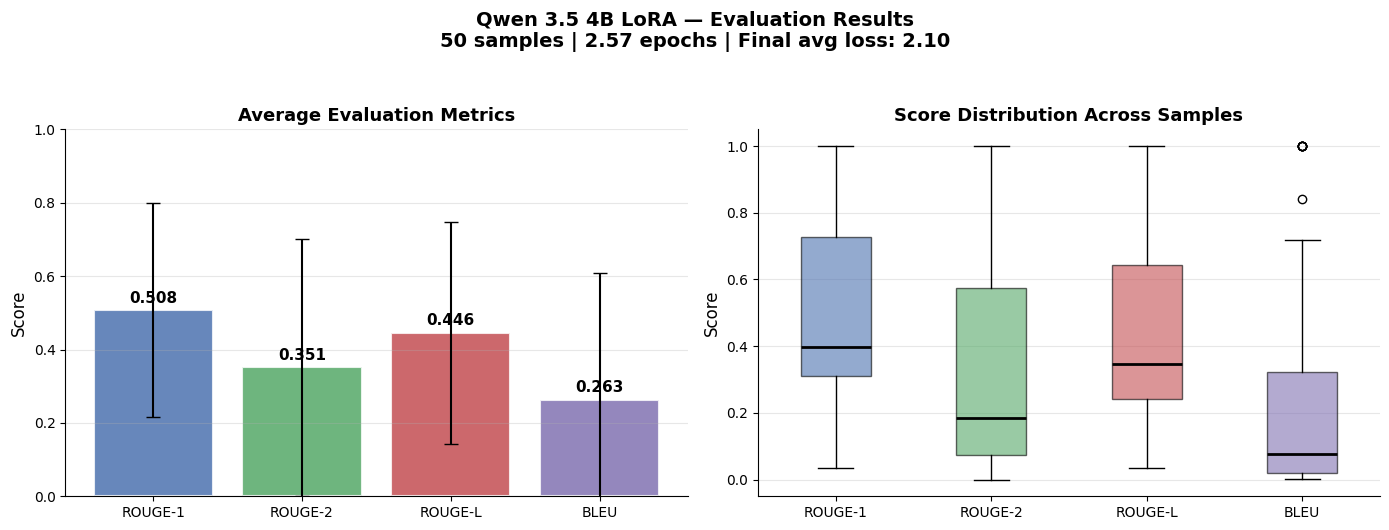

In [14]:
# ── FIGURE 3: Evaluation Metrics Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average scores bar chart
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
means = [np.mean(rouge1_scores), np.mean(rouge2_scores),
         np.mean(rougeL_scores), np.mean(bleu_scores)]
stds = [np.std(rouge1_scores), np.std(rouge2_scores),
        np.std(rougeL_scores), np.std(bleu_scores)]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[0].bar(metrics, means, yerr=stds, color=colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5, capsize=5)
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{mean:.3f}', ha='center', fontweight='bold', fontsize=11)

axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Average Evaluation Metrics', fontsize=13, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Right: Score distribution box plot
box_data = [rouge1_scores, rouge2_scores, rougeL_scores, bleu_scores]
bp = axes[1].boxplot(box_data, labels=metrics, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Score Distribution Across Samples', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Qwen 3.5 4B LoRA — Evaluation Results\n'
             f'{len(results)} samples | 2.57 epochs | Final avg loss: {np.mean(losses[-20:]):.2f}',
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

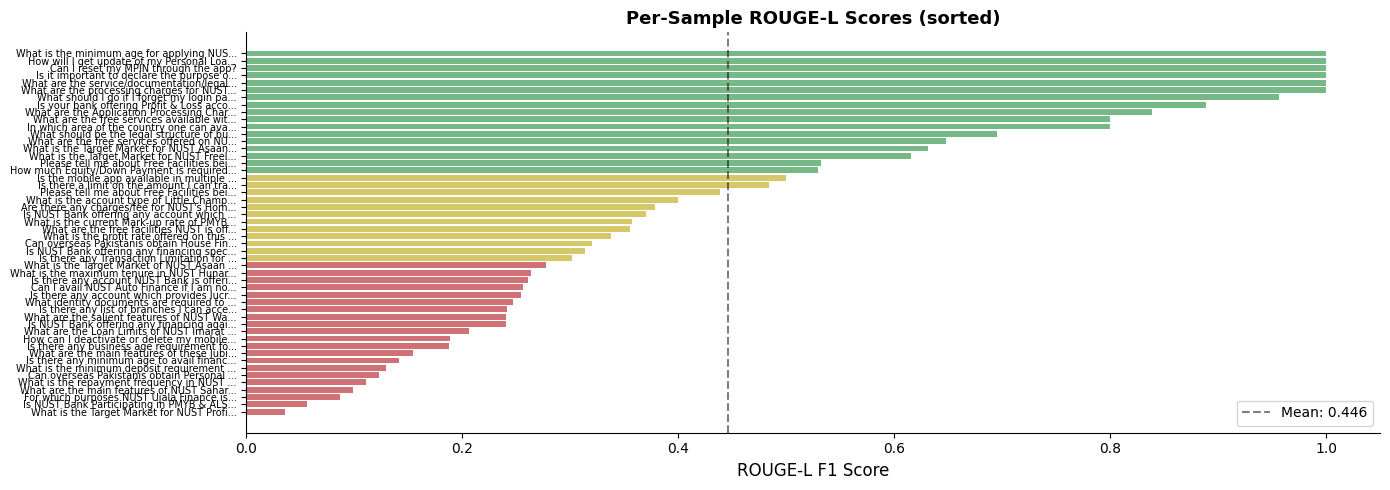


Quality breakdown:
  High (ROUGE-L > 0.5): 17/50 (34%)
  Medium (0.3-0.5):     12/50 (24%)
  Low (< 0.3):          21/50 (42%)


In [19]:
# ── FIGURE 4: Per-sample ROUGE-L scores (sorted) ──
fig, ax = plt.subplots(figsize=(14, 5))

sorted_results = sorted(results, key=lambda x: x['rougeL'], reverse=True)
sample_labels = [r['question'][:40] + '...' if len(r['question']) > 40 else r['question']
                 for r in sorted_results]
rougeL_sorted = [r['rougeL'] for r in sorted_results]

# Color code: green > 0.5, yellow 0.3-0.5, red < 0.3
bar_colors = ['#55A868' if s > 0.5 else '#CCBB44' if s > 0.3 else '#C44E52'
              for s in rougeL_sorted]

ax.barh(range(len(rougeL_sorted)), rougeL_sorted, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(sample_labels)))
ax.set_yticklabels(sample_labels, fontsize=7)
ax.set_xlabel('ROUGE-L F1 Score', fontsize=12)
ax.set_title('Per-Sample ROUGE-L Scores (sorted)', fontsize=13, fontweight='bold')
ax.axvline(x=np.mean(rougeL_sorted), color='black', linestyle='--', alpha=0.5,
           label=f'Mean: {np.mean(rougeL_sorted):.3f}')
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('per_sample_rougeL.png', dpi=150, bbox_inches='tight')
plt.show()

# Count quality buckets
high = sum(1 for s in rougeL_sorted if s > 0.5)
med = sum(1 for s in rougeL_sorted if 0.3 <= s <= 0.5)
low = sum(1 for s in rougeL_sorted if s < 0.3)
print(f'\nQuality breakdown:')
print(f'  High (ROUGE-L > 0.5): {high}/{len(results)} ({high/len(results)*100:.0f}%)')
print(f'  Medium (0.3-0.5):     {med}/{len(results)} ({med/len(results)*100:.0f}%)')
print(f'  Low (< 0.3):          {low}/{len(results)} ({low/len(results)*100:.0f}%)')

In [21]:
# ── Show top 5 best and worst predictions ──
print('=' * 70)
print('  TOP 5 BEST PREDICTIONS (highest ROUGE-L)')
print('=' * 70)
for r in sorted_results[:5]:
    print(f'\nQ: {r["question"]}')
    print(f'Expected: {r["ground_truth"][:150]}...' if len(r['ground_truth']) > 150 else f'Expected: {r["ground_truth"]}')
    print(f'Got:      {r["predicted"][:150]}...' if len(r['predicted']) > 150 else f'Got:      {r["predicted"]}')
    print(f'ROUGE-L: {r["rougeL"]:.3f} | BLEU: {r["bleu"]:.3f}')
    print('-' * 70)

print(f'\n{"=" * 70}')
print('  TOP 5 WORST PREDICTIONS (lowest ROUGE-L)')
print('=' * 70)
for r in sorted_results[-5:]:
    print(f'\nQ: {r["question"]}')
    print(f'Expected: {r["ground_truth"][:150]}...' if len(r['ground_truth']) > 150 else f'Expected: {r["ground_truth"]}')
    print(f'Got:      {r["predicted"][:150]}...' if len(r['predicted']) > 150 else f'Got:      {r["predicted"]}')
    print(f'ROUGE-L: {r["rougeL"]:.3f} | BLEU: {r["bleu"]:.3f}')
    print('-' * 70)

  TOP 5 BEST PREDICTIONS (highest ROUGE-L)

Q: What is the minimum age for applying NUST Mortgage Finance?
Expected: Salaried : 21 Years
SEB/SEP: 23 Years
Got:      Salaried: 21 years
SEB/SEP: 23 Years
ROUGE-L: 1.000 | BLEU: 1.000
----------------------------------------------------------------------

Q: How will I get update of my Personal Loan Application?
Expected: You can visit/ call or send email at our Customer Services centre(s) as well.
Email Address: CustomerServices@NUSTbank.com.pk
Got:      You can visit/ call or send email at our Customer Services centre(s) as well.
Email Address: CustomerServices@NUSTbank.com.pk
ROUGE-L: 1.000 | BLEU: 1.000
----------------------------------------------------------------------

Q: Can I reset my MPIN through the app?
Expected: Yes, after logging into the app, go to 'Profile' → 'Change MPIN' and follow the prompts to reset your MPIN securely.
Got:      Yes, after logging into the app, go to 'Profile' → 'Change MPIN' and follow the prompts t

In [22]:
# ── Save full results to CSV for reference ──
import csv

with open('evaluation_results.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Question', 'Ground Truth', 'Predicted', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU'])
    for r in results:
        writer.writerow([
            r['question'], r['ground_truth'], r['predicted'],
            f"{r['rouge1']:.4f}", f"{r['rouge2']:.4f}", f"{r['rougeL']:.4f}", f"{r['bleu']:.4f}"
        ])

print('Full results saved to: evaluation_results.csv')

# ── Final Summary Card (for presentation) ──
print(f'\n{"=" * 60}')
print(f'  FINE-TUNING SUMMARY CARD')
print(f'{"=" * 60}')
print(f'  Model:            Qwen 3.5 4B')
print(f'  Method:           LoRA (r=8, alpha=16)')
print(f'  Dataset:          310 NUST Bank Q&A pairs')
print(f'  Training:         199 steps (~2.57 epochs)')
print(f'  GPU:              NVIDIA RTX 4060 Laptop (8GB)')
print(f'  Initial Loss:     {losses[0]:.2f}')
print(f'  Final Loss:       {np.mean(losses[-20:]):.2f} (avg last 20)')
print(f'  Loss Reduction:   {((losses[0] - np.mean(losses[-20:])) / losses[0] * 100):.1f}%')
print(f'  ─── Evaluation ───')
print(f'  ROUGE-1:          {np.mean(rouge1_scores):.4f}')
print(f'  ROUGE-2:          {np.mean(rouge2_scores):.4f}')
print(f'  ROUGE-L:          {np.mean(rougeL_scores):.4f}')
print(f'  BLEU:             {np.mean(bleu_scores):.4f}')
print(f'{"=" * 60}')

Full results saved to: evaluation_results.csv

  FINE-TUNING SUMMARY CARD
  Model:            Qwen 3.5 4B
  Method:           LoRA (r=8, alpha=16)
  Dataset:          310 NUST Bank Q&A pairs
  Training:         199 steps (~2.57 epochs)
  GPU:              NVIDIA RTX 4060 Laptop (8GB)
  Initial Loss:     11.04
  Final Loss:       2.10 (avg last 20)
  Loss Reduction:   81.0%
  ─── Evaluation ───
  ROUGE-1:          0.5080
  ROUGE-2:          0.3512
  ROUGE-L:          0.4459
  BLEU:             0.2630
